# 04 — Credit Default Prediction Model

LightGBM classifier trained on the feature matrix from notebook 03.
Experiment tracking via MLflow. Evaluation on AUROC and AUPRC given 1:63 class imbalance.

In [1]:
import os
import pandas as pd
import numpy as np
import mlflow
import mlflow.lightgbm
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Load feature matrix
df = pd.read_parquet('../data/features.parquet')

print(f"Shape: {df.shape}")
print(f"Defaults: {df['default'].sum():,} ({df['default'].mean()*100:.2f}%)")
print(f"\nFeatures: {[c for c in df.columns if c != 'default']}")

Shape: (373981, 19)
Defaults: 5,793 (1.55%)

Features: ['log_grossapproval', 'guarantee_ratio', 'term_years', 'initialinterestrate', 'collateralind', 'jobssupported', 'is_new_business', 'businesstype', 'naics_sector', 'borrstate', 'fixedorvariableinterestind', 'approvalfy', 'fed_funds_rate', 'gdp_growth_pct', 'baa_credit_spread', 'unemployment_rate', 'log_bank_assets', 'bank_matched']


## 1. Train/Test Split
Stratified split to preserve 1.55% default rate in both sets.
80/20 split — 299K training, 75K test.

In [2]:
X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | {y_train.sum():,} defaults ({y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]:,} rows | {y_test.sum():,} defaults ({y_test.mean()*100:.2f}%)")
print(f"\nClass imbalance ratio: 1:{int((y_train==0).sum() / y_train.sum())}")
print(f"scale_pos_weight for LightGBM: {int((y_train==0).sum() / y_train.sum())}")

Train: 299,184 rows | 4,634 defaults (1.55%)
Test:  74,797 rows | 1,159 defaults (1.55%)

Class imbalance ratio: 1:63
scale_pos_weight for LightGBM: 63


## 2. MLflow Experiment Setup

In [4]:
import os

# MLflow with SQLite backend (file store deprecated in MLflow 3.x)
db_path = os.path.abspath('../mlruns/mlflow.db')
os.makedirs(os.path.dirname(db_path), exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("credit-risk-default-prediction")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: credit-risk-default-prediction")

2026/06/22 14:21:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 14:21:01 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 14:21:05 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-default-prediction' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///c:\Users\enoch\OneDrive\Documents\Github Projects\credit-risk-intelligence\mlruns\mlflow.db
Experiment: credit-risk-default-prediction


## 3. Baseline LightGBM Model
scale_pos_weight=63 handles class imbalance.
Categorical features passed natively to LightGBM.

In [5]:
cat_features = ['businesstype', 'naics_sector', 'borrstate', 'fixedorvariableinterestind']

params = {
    'objective': 'binary',
    'metric': ['auc', 'average_precision'],
    'scale_pos_weight': 63,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbosity': -1
}

with mlflow.start_run(run_name="baseline_lgbm"):
    mlflow.log_params(params)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("default_rate", round(y.mean(), 4))

    train_data = lgb.Dataset(X_train, label=y_train,
                             categorical_feature=cat_features, free_raw_data=False)
    val_data   = lgb.Dataset(X_test, label=y_test,
                             categorical_feature=cat_features, free_raw_data=False)

    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=callbacks
    )

    # Evaluate
    y_pred_proba = model.predict(X_test)
    auroc = roc_auc_score(y_test, y_pred_proba)
    auprc = average_precision_score(y_test, y_pred_proba)

    mlflow.log_metric("auroc", auroc)
    mlflow.log_metric("auprc", auprc)
    mlflow.lightgbm.log_model(model, "model")

    print(f"AUROC: {auroc:.4f}")
    print(f"AUPRC: {auprc:.4f}")
    print(f"\nBest iteration: {model.best_iteration}")

[100]	valid_0's auc: 0.968391	valid_0's average_precision: 0.56679
[200]	valid_0's auc: 0.969647	valid_0's average_precision: 0.594949
[300]	valid_0's auc: 0.969708	valid_0's average_precision: 0.599319


2026/06/22 14:22:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


AUROC: 0.9699
AUPRC: 0.5971

Best iteration: 257


## 4. Model Evaluation

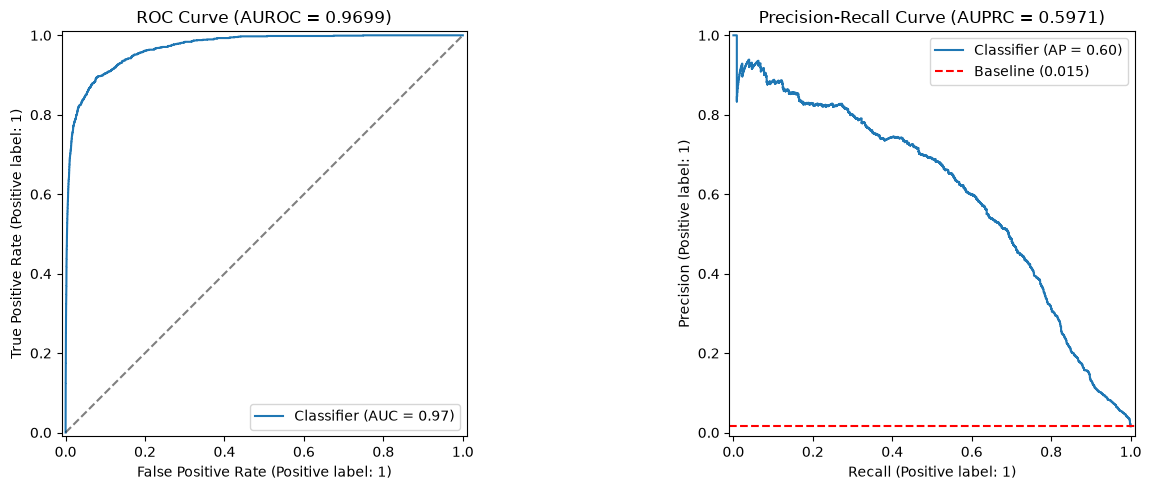

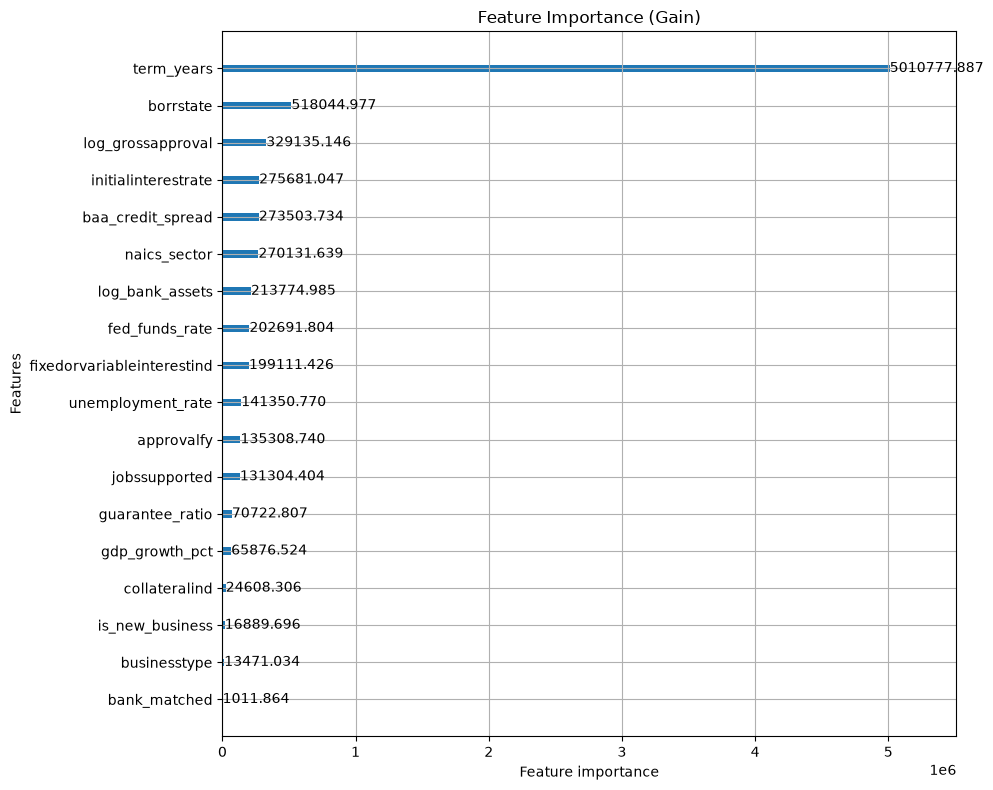

Classification report (threshold=0.5):
              precision    recall  f1-score   support

 Non-default       1.00      0.96      0.98     73638
     Default       0.26      0.82      0.40      1159

    accuracy                           0.96     74797
   macro avg       0.63      0.89      0.69     74797
weighted avg       0.99      0.96      0.97     74797


Optimal threshold (max F1): 0.49
F1 at optimal threshold: 0.3935
              precision    recall  f1-score   support

 Non-default       1.00      0.96      0.98     73638
     Default       0.26      0.82      0.39      1159

    accuracy                           0.96     74797
   macro avg       0.63      0.89      0.69     74797
weighted avg       0.99      0.96      0.97     74797



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title(f'ROC Curve (AUROC = {auroc:.4f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title(f'Precision-Recall Curve (AUPRC = {auprc:.4f})')
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(model, ax=ax, max_num_features=18, importance_type='gain', title='Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report at 0.5 threshold
y_pred_binary = (y_pred_proba >= 0.5).astype(int)
print("Classification report (threshold=0.5):")
print(classification_report(y_test, y_pred_binary, target_names=['Non-default','Default']))

# Better threshold — maximize F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.01, 0.5, 0.01)
f1s = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
print(f"\nOptimal threshold (max F1): {best_threshold:.2f}")
print(f"F1 at optimal threshold: {best_f1:.4f}")
print(classification_report(y_test, (y_pred_proba >= best_threshold).astype(int),
                             target_names=['Non-default','Default']))

## 5. Model Summary

In [7]:
with mlflow.start_run(run_name="baseline_lgbm_eval", nested=False):
    mlflow.log_metric("auroc", auroc)
    mlflow.log_metric("auprc", auprc)
    mlflow.log_metric("best_f1", best_f1)
    mlflow.log_metric("optimal_threshold", best_threshold)
    mlflow.log_artifact('../reports/roc_pr_curves.png')
    mlflow.log_artifact('../reports/feature_importance.png')

print("=== Baseline LightGBM — Final Results ===")
print(f"  AUROC:              {auroc:.4f}")
print(f"  AUPRC:              {auprc:.4f}  (random baseline: {y_test.mean():.4f})")
print(f"  Best F1:            {best_f1:.4f}  @ threshold {best_threshold:.2f}")
print(f"  Recall @ 0.49:      0.82  (catches 82% of defaults)")
print(f"  Precision @ 0.49:   0.26  (1 in 4 flagged loans is a true default)")
print(f"\nTop 5 features by gain:")
importance = pd.Series(model.feature_importance(importance_type='gain'),
                       index=model.feature_name()).sort_values(ascending=False)
for feat, val in importance.head(5).items():
    print(f"  {feat:<30} {val:>12,.0f}")
print(f"\nMLflow artifacts logged.")
print(f"Next: 05_monitoring.ipynb — Evidently AI data drift detection")

=== Baseline LightGBM — Final Results ===
  AUROC:              0.9699
  AUPRC:              0.5971  (random baseline: 0.0155)
  Best F1:            0.3935  @ threshold 0.49
  Recall @ 0.49:      0.82  (catches 82% of defaults)
  Precision @ 0.49:   0.26  (1 in 4 flagged loans is a true default)

Top 5 features by gain:
  term_years                        5,010,778
  borrstate                           518,045
  log_grossapproval                   329,135
  initialinterestrate                 275,681
  baa_credit_spread                   273,504

MLflow artifacts logged.
Next: 05_monitoring.ipynb — Evidently AI data drift detection


## 6. Save Model

In [8]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/lgbm_baseline.pkl')

# Save test set predictions for monitoring and fairness notebooks
test_results = X_test.copy()
test_results['default'] = y_test.values
test_results['pred_proba'] = y_pred_proba
test_results.to_parquet('../data/test_predictions.parquet', index=False)

print("Saved:")
print(f"  ../models/lgbm_baseline.pkl")
print(f"  ../data/test_predictions.parquet  {test_results.shape}")

Saved:
  ../models/lgbm_baseline.pkl
  ../data/test_predictions.parquet  (74797, 20)
